In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

In [2]:
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv("smartcart_customers.csv")

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df.shape

(2240, 22)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# Data preprocessing

In [8]:
# Missing value
df["Income"]= df["Income"].fillna(df["Income"].median())

# Feature Engg.

In [10]:
# Adding Age 
df["Age"]= 2026-df["Year_Birth"]

In [11]:
# Making dates easy to process 
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"], dayfirst=True) # since pandas expects month first so here we have to tell it. 

reference_date= df["Dt_Customer"].max() # we could have taken todays date using know() but this will take new date everyday causing chang in results. 

df["customer_tenure_date"]= (reference_date-df["Dt_Customer"]).dt.days # to get total no. of days customer has joined the platform.

In [12]:
# Spending calculation using all sold items ,along with combining total keeds and teenagers 

df["Total_Spending"]= df["MntFruits"]+df["MntFishProducts"]+df["MntGoldProds"]+df["MntMeatProducts"]+df["MntSweetProducts"]+df["MntWines"]

df["Total_Children"]= df["Kidhome"]=df["Teenhome"]

In [13]:
# Minimising Education Catogories
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [14]:
# Reducing them to- Undergrad, Grad and Postgrad 
df["Education"]=df["Education"].replace({
     "Basic":"Undergraduate","2n Cycle":"Undergraduate", 
    "Graduation":"Graduate", 
    "Master":"Postgraduate","PhD":"Postgraduate"
})

In [15]:
# Similarly doing with Marital status 
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [16]:
df["Living_With"]=df["Marital_Status"].replace({
     "Married":"Partner","Together":"Partner", 
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})

# Drop Columns

In [87]:
cols= ["Teenhome","ID","Year_Birth","Marital_Status","Kidhome","Dt_Customer","MntFruits","MntFishProducts","MntGoldProds","MntMeatProducts","MntSweetProducts","MntWines"]

df_cleaned=df.drop(columns=cols)

In [89]:
df_cleaned.shape

(2240, 15)

In [91]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_date,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,1,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,0,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,0,Partner


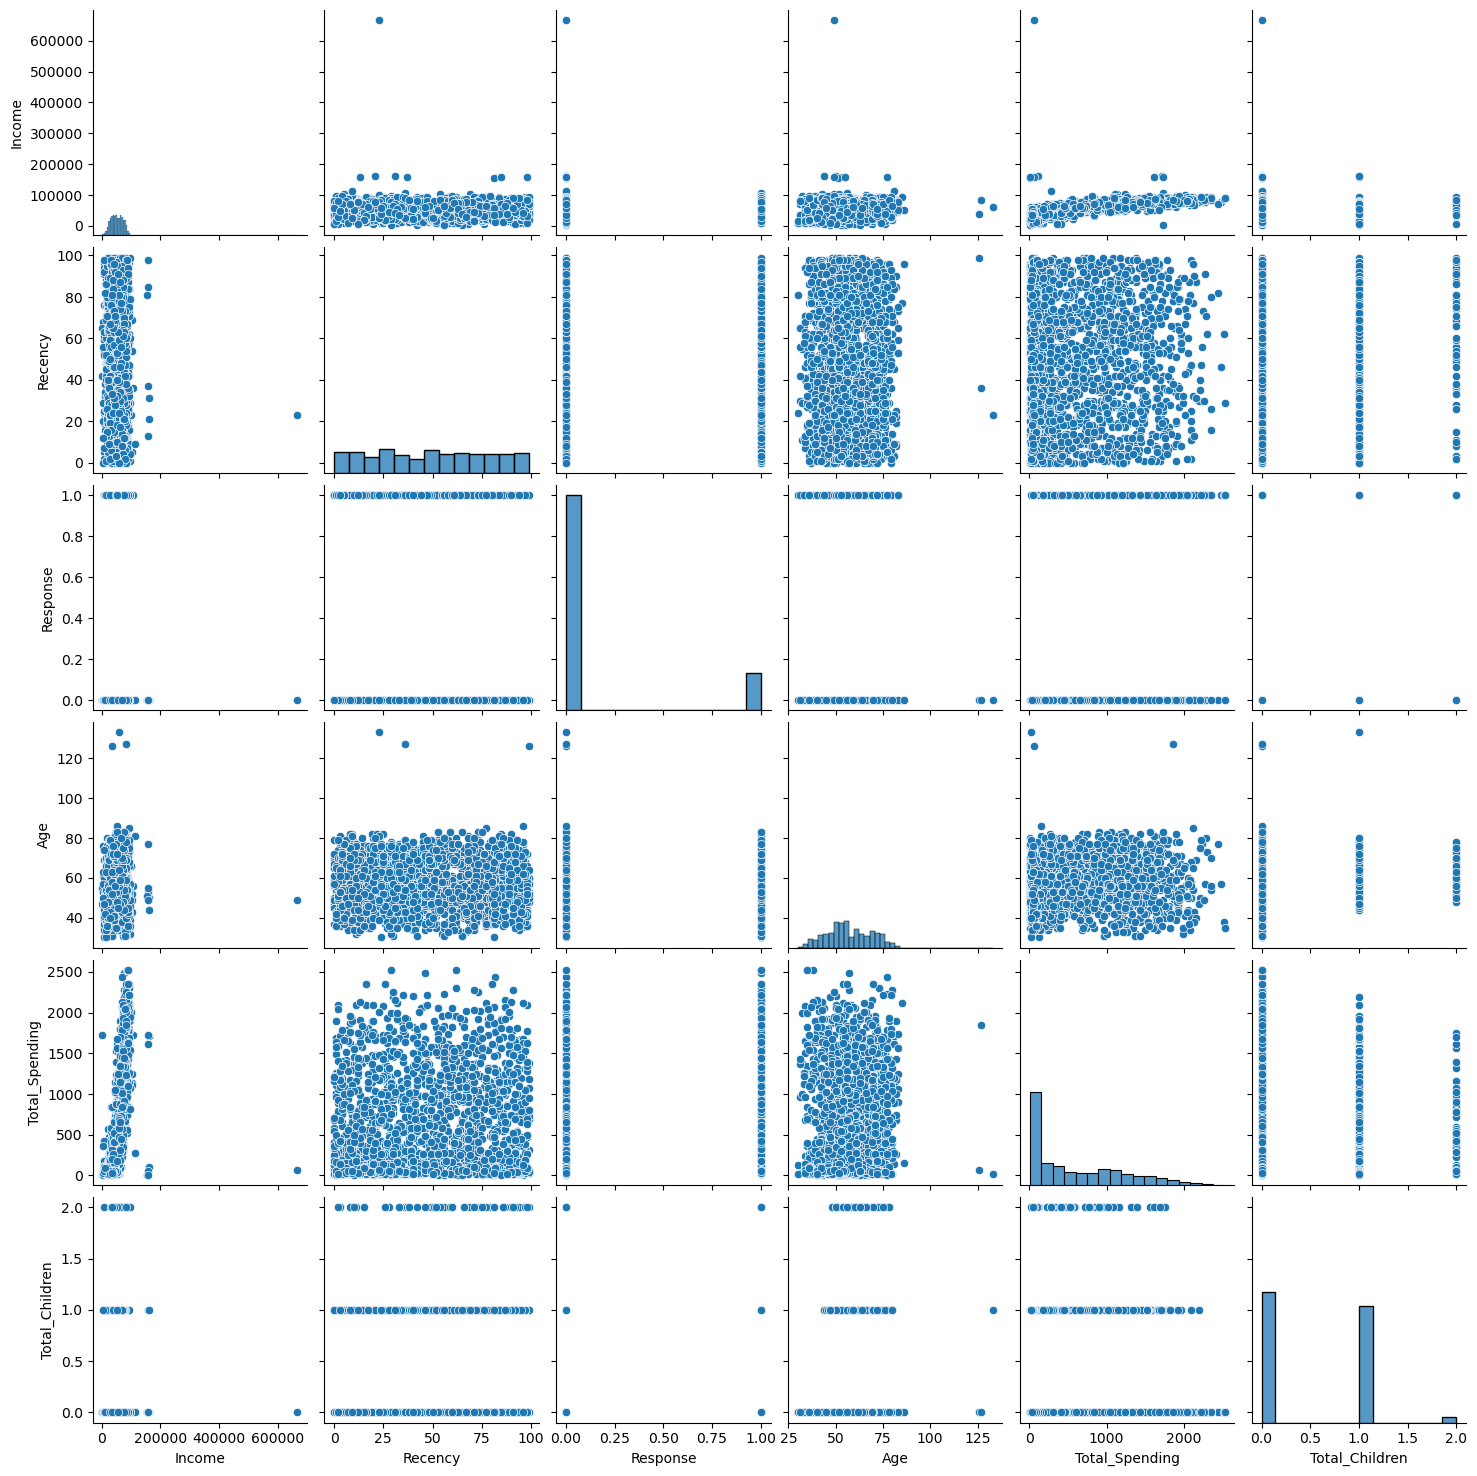

In [93]:
# Handeling Outliers using pair(relative) plots for those cols whose relation cant be sensed just by there names 

col= ["Income","Recency","Response","Age","Total_Spending","Total_Children"]
sns.pairplot(df_cleaned[col])

In [94]:
# Here know we can pin point outliers ,and many of them are cought and will be removed. 
print("No. of values :",len(df_cleaned))
df_cleaned= df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned= df_cleaned[(df_cleaned["Income"]<600_000)]

print("No. of values :",len(df_cleaned))

No. of values : 2240
No. of values : 2236


# Heatmap

<Axes: >

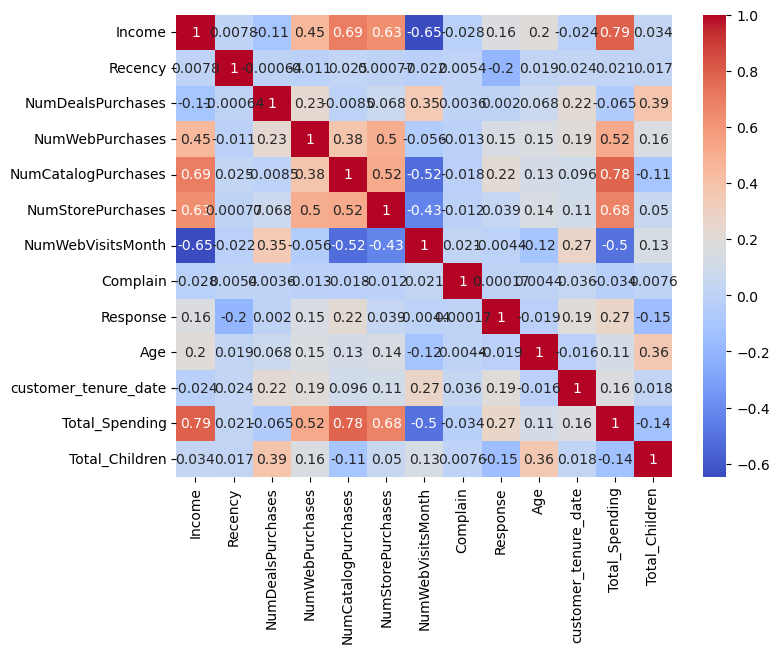

In [98]:
corr= df_cleaned.corr(numeric_only=True) 

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True, 
    cmap="coolwarm"
)

# Encoding

In [100]:
from sklearn.preprocessing import OneHotEncoder 

one= OneHotEncoder()

cat_cols= ["Education","Living_With"]

enc_cols= one.fit_transform(df_cleaned[cat_cols])

enc_df= pd.DataFrame(enc_cols.toarray(), columns=one.get_feature_names_out(cat_cols), index= df_cleaned.index)

In [102]:
df_enc=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis= 1)

In [104]:
df_enc.shape

(2236, 18)

# Scaling

In [107]:
from sklearn.preprocessing import StandardScaler

X= df_enc
scaler= StandardScaler()
X_sca= scaler.fit_transform(X)

# Visualisation

In [110]:
# For 2D visials we will use PCA 
from sklearn.decomposition import PCA 

pca= PCA(n_components=2)

X_pca= pca.fit_transform(X_sca)

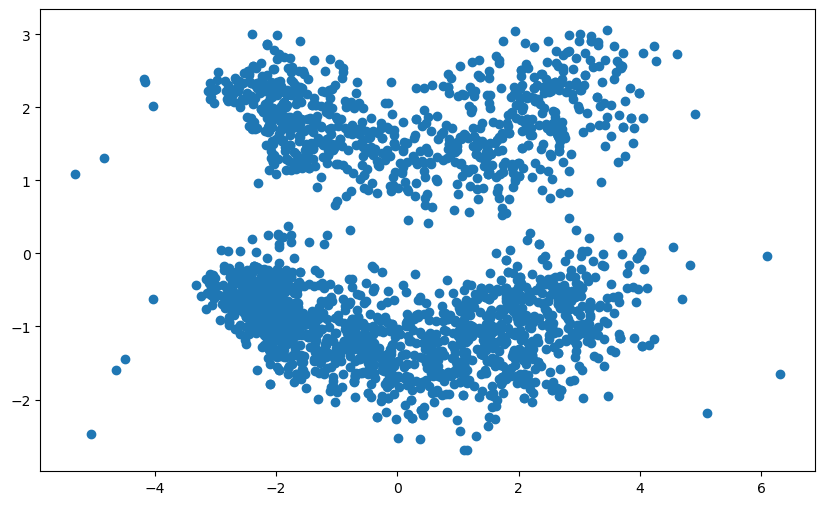

In [112]:
plt.figure(figsize=(10,6))

plt.scatter(X_pca[:,0],X_pca[:,1])

In [114]:
pca.explained_variance_ratio_

array([0.21712305, 0.1147296 ])

In [116]:
# 3D visuals 
pca= PCA(n_components=3)

X_pca= pca.fit_transform(X_sca)

pca.explained_variance_ratio_

array([0.21712305, 0.11472961, 0.10756959])

Text(0.5, 0.92, '3D Projection')

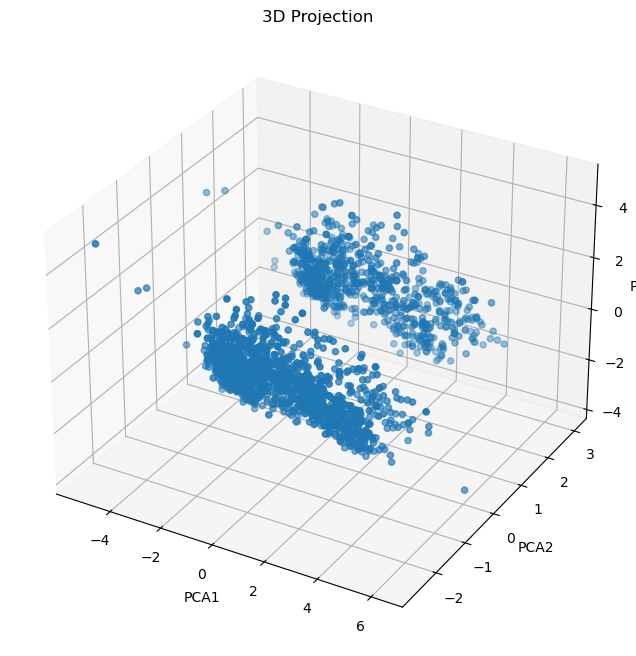

In [118]:
fig= plt.figure(figsize=(12,8))

ax= fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2") 
ax.set_zlabel("PCA3") 
ax.set_title("3D Projection")

# Finding K-value
## 1.Elbow method

In [121]:
from sklearn.cluster import KMeans 
from kneed import KneeLocator

wcss=[]
for k in range(1,11): 
    kmeans= KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [123]:
knee= KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
knee.elbow

4

## 2.Silhouette Score

In [126]:
from sklearn.metrics import silhouette_score 

scores= []
for k in range(2,11): 
    kmeans= KMeans(n_clusters=k, random_state=42)
    labels= kmeans.fit_predict(X_pca)
    score= silhouette_score(X_pca, labels)
    scores.append(score)

Text(0, 0.5, 'SS')

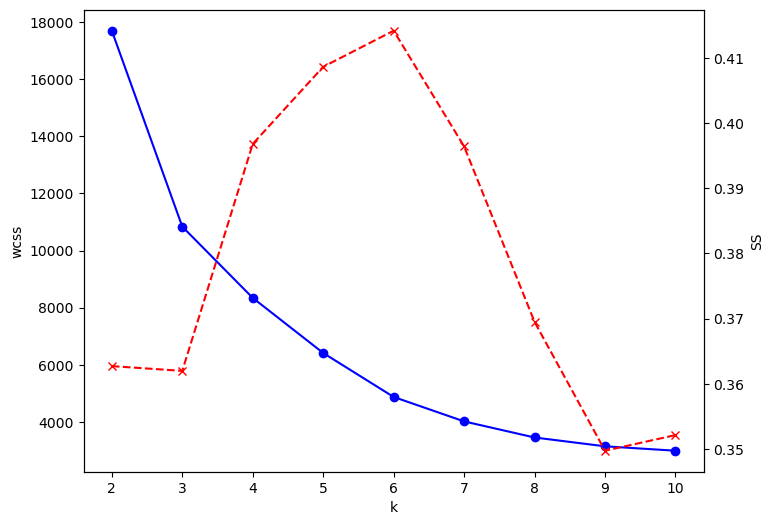

In [128]:
# combined plot 
k_range= range(2,11)
fig,ax1= plt.subplots(figsize=(8,6)) 
ax1.plot(k_range, wcss[:len(k_range)],marker="o", color= "blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2= ax1.twinx() # this means keeping the x axis same
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="Red", linestyle="--")
ax2.set_ylabel("SS")

# Clusturing

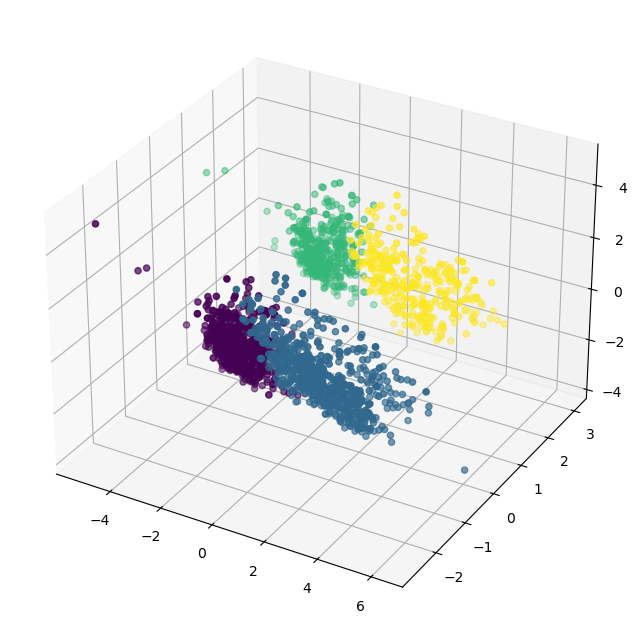

In [139]:
# kmeans 
kmeans= KMeans(n_clusters=4, random_state=42)
labels_final= kmeans.fit_predict(X_pca)

fig= plt.figure(figsize=(12,8))

ax= fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2], c=labels_final)

In [133]:
# Agglomerative 
from sklearn.cluster import AgglomerativeClustering 

agg= AgglomerativeClustering(n_clusters=4, linkage= "ward")
label_agg= agg.fit_predict(X_pca)

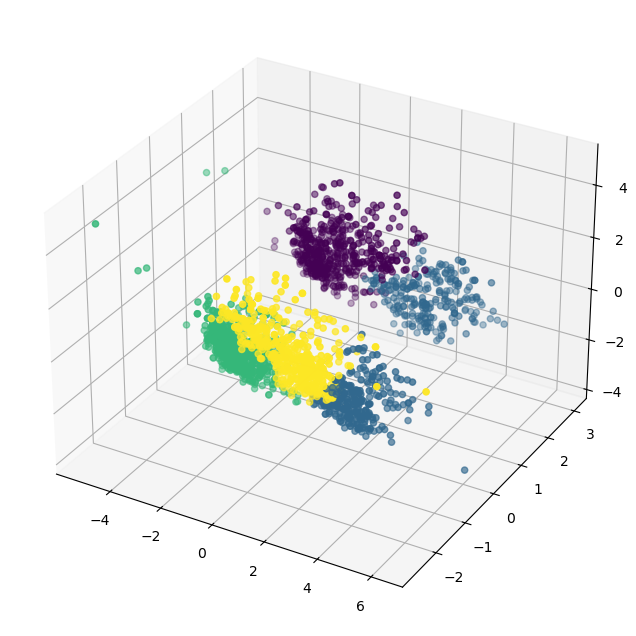

In [135]:
fig= plt.figure(figsize=(12,8))

ax= fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2], c=label_agg)

We can see kmeans is producing better clusters so we will proceed with that.

# Characterization of customer clustures

In [156]:
X["Clustur"]= labels_final

<Axes: xlabel='Clustur', ylabel='count'>

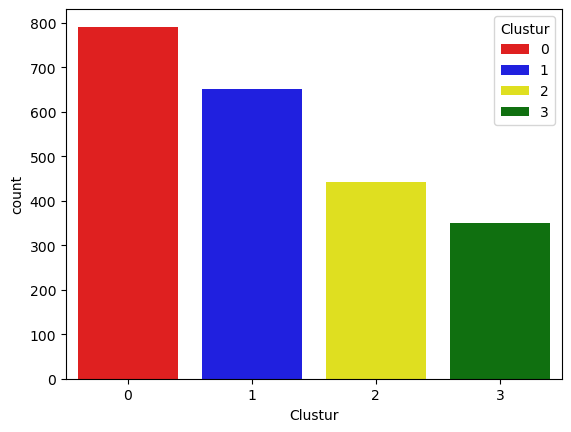

In [158]:
# Extractng imp. info. form the clusters 
pal =["red","blue","yellow","green"]
sns.countplot(x=X["Clustur"], palette=pal, hue= X["Clustur"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

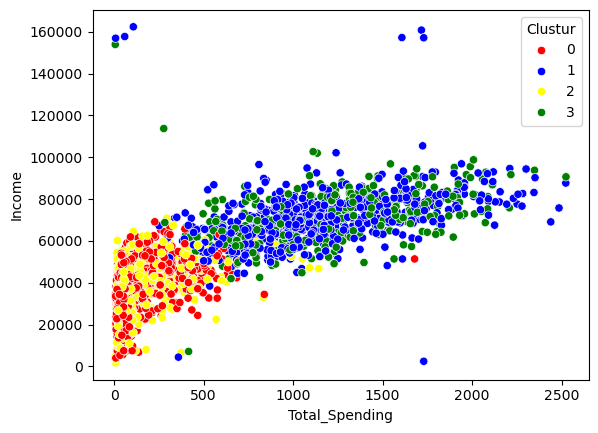

In [160]:
# Through heatmap we know Income and spending patterns are most related. 
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["Clustur"], palette=pal) # using the hue with our colors

We can see low income goups 0&2 are also spending very less incomparision to group 1&3 who are more earning also.

In [164]:
# Cluster summary
cluster_summ= X.groupby("Clustur").mean()
print(cluster_summ)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clustur                                                                
0        36595.925411  49.065740           2.386852         2.683944   
1        70445.105991  49.007680           2.337942         5.789555   
2        37137.638826  48.194131           2.528217         2.729120   
3        70959.914530  50.595442           1.911681         5.809117   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clustur                                                                        
0                   0.707965           3.640961           6.512010  0.010114   
1                   4.996928           8.440860           3.883257  0.007680   
2                   0.835214           3.661400           6.573363  0.011287   
3                   5.048433           8.438746           3.709402  0.005698   

         Response        Age  customer_tenure_date  Total_Spending  \
Clustur         